In [ ]:
# ════════════════════════════════════════════════
#  CELL 1 — Kaggle Auth & Dataset Download
# ════════════════════════════════════════════════
!pip install kaggle -q

import os
from google.colab import files

print("📂 Upload your kaggle.json:")
uploaded = files.upload()

os.makedirs("/root/.config/kaggle", exist_ok=True)
with open("/root/.config/kaggle/kaggle.json", "wb") as f:
    f.write(list(uploaded.values())[0])
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)
print("✅ Kaggle auth done")

# Download dataset
!#!/bin/bash
!kaggle datasets download harshrajbhar/freshness -p /content/freshness --unzip -q
print("✅ Dataset downloaded to /content/freshness")

# Show top-level structure
for root, dirs, files_ in os.walk("/content/freshness"):
    depth = root.replace("/content/freshness", "").count(os.sep)
    if depth > 2:
        continue
    pad = "  " * depth
    print(f"{pad}{os.path.basename(root)}/  [{len(files_)} files]")
    dirs.sort()

📂 Upload your kaggle.json:


Saving kaggle.json to kaggle.json
✅ Kaggle auth done
Dataset URL: https://www.kaggle.com/datasets/harshrajbhar/freshness
License(s): apache-2.0
✅ Dataset downloaded to /content/freshness
freshness/  [0 files]
  Freshness/  [0 files]
    Apple/  [0 files]
    Grapes/  [0 files]
    Lemon/  [0 files]
    Mango/  [0 files]
    Papaya/  [0 files]
    Paprika Pepper/  [0 files]
    Strawberry/  [0 files]
    Tomato/  [0 files]
    Watermelon/  [0 files]
  Temp/  [9 files]


In [ ]:
# ════════════════════════════════════════════════
#  CELL 1 — Restructure Dataset
#  FROM: /content/freshness/Freshness/Apple/DAY_1/
#  TO:   /content/dataset/apple/day_1/
# ════════════════════════════════════════════════
import re, shutil
from pathlib import Path

FRUIT_CUTOFF = {
    'grapes' : 20
}

SOURCE_ROOT = Path("/content/freshness/Freshness")
DEST_ROOT   = Path("/content/dataset")
IMG_EXTS    = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

total_copied = 0
total_skipped = 0

for fruit_dir in sorted(SOURCE_ROOT.iterdir()):
    if not fruit_dir.is_dir():
        continue

    # Match to fruit key  e.g.  "Apple" → "apple",  "Paprika_Pepper" → "paprika_pepper"
    fname = fruit_dir.name.lower().replace(" ", "_").replace("-", "_")
    matched_key = None
    for key in FRUIT_CUTOFF:
        if key == fname or key in fname or fname in key:
            matched_key = key
            break

    if matched_key is None:
        print(f"⚠️  Skipping unrecognised: {fruit_dir.name}")
        continue

    cutoff = FRUIT_CUTOFF[matched_key]
    print(f"\n📁 {fruit_dir.name}  →  {matched_key}  (cutoff = day {cutoff})")

    for day_dir in sorted(fruit_dir.iterdir()):
        if not day_dir.is_dir():
            continue

        m = re.search(r'(\d+)', day_dir.name)
        if not m:
            continue
        day_num = int(m.group(1))

        if day_num > cutoff:
            print(f"   ✂️  Dropping {day_dir.name}  (day {day_num} > cutoff {cutoff})")
            total_skipped += 1
            continue

        dest = DEST_ROOT / matched_key / f"day_{day_num}"
        dest.mkdir(parents=True, exist_ok=True)

        imgs = [p for p in day_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
        for img in imgs:
            shutil.copy2(img, dest / img.name)
            total_copied += 1

        print(f"   ✅  {day_dir.name}  →  day_{day_num}/  [{len(imgs)} images]")

# ── Summary ──────────────────────────────────────
print(f"\n{'═'*45}")
print(f"✅ Done!  Copied: {total_copied}  |  Dropped days: {total_skipped}")
print(f"{'═'*45}")

# ── Verify ───────────────────────────────────────
print("\n📂 Final structure:")
for fruit_dir in sorted(DEST_ROOT.iterdir()):
    day_dirs = sorted(fruit_dir.iterdir(),
                      key=lambda p: int(re.search(r'\d+', p.name).group()))
    total = sum(len(list(d.iterdir())) for d in day_dirs)
    days  = [d.name for d in day_dirs]
    print(f"  {fruit_dir.name:20s}  days={days}  total_imgs={total}")

⚠️  Skipping unrecognised: Apple

📁 Grapes  →  grapes  (cutoff = day 20)
   ✅  DAY_1  →  day_1/  [64 images]
   ✅  DAY_10  →  day_10/  [64 images]
   ✅  DAY_11  →  day_11/  [64 images]
   ✅  DAY_12  →  day_12/  [64 images]
   ✅  DAY_13  →  day_13/  [64 images]
   ✅  DAY_14  →  day_14/  [64 images]
   ✅  DAY_15  →  day_15/  [64 images]
   ✅  DAY_16  →  day_16/  [64 images]
   ✅  DAY_17  →  day_17/  [64 images]
   ✅  DAY_18  →  day_18/  [64 images]
   ✅  DAY_19  →  day_19/  [64 images]
   ✅  DAY_2  →  day_2/  [64 images]
   ✅  DAY_20  →  day_20/  [64 images]
   ✂️  Dropping DAY_21  (day 21 > cutoff 20)
   ✂️  Dropping DAY_22  (day 22 > cutoff 20)
   ✂️  Dropping DAY_23  (day 23 > cutoff 20)
   ✂️  Dropping DAY_24  (day 24 > cutoff 20)
   ✂️  Dropping DAY_25  (day 25 > cutoff 20)
   ✂️  Dropping DAY_26  (day 26 > cutoff 20)
   ✂️  Dropping DAY_27  (day 27 > cutoff 20)
   ✂️  Dropping DAY_28  (day 28 > cutoff 20)
   ✅  DAY_3  →  day_3/  [64 images]
   ✅  DAY_4  →  day_4/  [64 images]
   ✅ 

In [ ]:
# ════════════════════════════════════════════════
#  CELL 2 — Apple Freshness CNN (Regression)
#  Input  : 224x224 apple image
#  Output : predicted day (1–15, float)
# ════════════════════════════════════════════════
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import re, warnings
warnings.filterwarnings("ignore")

# ── Config ───────────────────────────────────────
FRUIT       = "grapes"
CUTOFF      = 20
IMG_SIZE    = 224
BATCH_SIZE  = 16    # small batch suits 50-150 imgs/day
EPOCHS      = 40    # more epochs for small dataset
LR          = 2e-4
VAL_FRAC    = 0.15
TEST_FRAC   = 0.10
SEED        = 42
DATA_DIR    = Path(f"/content/dataset/{FRUIT}")
SAVE_PATH   = Path(f"/content/{FRUIT}_model.pt")
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device : {DEVICE}")
print(f"Fruit  : {FRUIT}  |  Cutoff day : {CUTOFF}")

# ── Transforms ───────────────────────────────────
# Aggressive augmentation because dataset is small
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.3, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1),
                            scale=(0.85, 1.15)),
    transforms.RandomGrayscale(p=0.03),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── Dataset ──────────────────────────────────────
class AppleDataset(Dataset):
    """
    Reads from /content/dataset/apple/day_1/ ... day_15/
    Target = day_number / CUTOFF  (normalised float in 0–1)
    """
    def __init__(self, samples, transform=None):
        self.samples   = samples   # list of (img_path_str, day_int)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, day = self.samples[idx]
        img    = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        target = torch.tensor(day / CUTOFF, dtype=torch.float32)
        return img, target

# Build sample list
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
samples  = []

print("\nLoading samples:")
for day_dir in sorted(DATA_DIR.iterdir(),
                      key=lambda p: int(re.search(r'\d+', p.name).group())):
    if not day_dir.is_dir():
        continue
    day_num = int(re.search(r'\d+', day_dir.name).group())
    imgs    = [p for p in day_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
    for p in imgs:
        samples.append((str(p), day_num))
    print(f"  day_{day_num:02d}  →  {len(imgs)} images")

print(f"\nTotal samples : {len(samples)}")

# Train / Val / Test split
n       = len(samples)
n_val   = max(2, int(n * VAL_FRAC))
n_test  = max(2, int(n * TEST_FRAC))
n_train = n - n_val - n_test
print(f"Split         : train={n_train}  val={n_val}  test={n_test}")

# Base dataset (no transform yet)
full_ds = AppleDataset(samples, transform=None)
tr_sub, va_sub, te_sub = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Wrapper to apply different transforms per split
class SplitWrapper(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        path, day = self.subset.dataset.samples[self.subset.indices[idx]]
        img    = Image.open(path).convert("RGB")
        target = torch.tensor(day / CUTOFF, dtype=torch.float32)
        return self.transform(img), target

train_ds = SplitWrapper(tr_sub, train_tfm)
val_ds   = SplitWrapper(va_sub, val_tfm)
test_ds  = SplitWrapper(te_sub, val_tfm)

kw = dict(num_workers=2, pin_memory=(DEVICE.type == "cuda"))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **kw)
print("✅ DataLoaders ready")

# ── Model ────────────────────────────────────────
def build_apple_model():
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Freeze all first
    for p in m.parameters():
        p.requires_grad = False

    # Unfreeze last 3 blocks (6, 7, 8) — learns texture + color decay
    for p in m.features[5:].parameters():
        p.requires_grad = True

    # Regression head
    in_feat = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feat, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
        nn.Sigmoid()      # output in (0,1] → multiply by CUTOFF = day
    )
    return m.to(DEVICE)

model = build_apple_model()
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

# ── Loss & Optimizer ─────────────────────────────
criterion = nn.SmoothL1Loss()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS, pct_start=0.15
)

# ── Train / Eval functions ───────────────────────
def mae_in_days(pred_norm, tgt_norm):
    return (torch.abs(pred_norm - tgt_norm) * CUTOFF).mean().item()

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_mae, n = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, tgts in loader:
            imgs = imgs.to(DEVICE)
            tgts = tgts.to(DEVICE).unsqueeze(1)
            preds = model(imgs)
            loss  = criterion(preds, tgts)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
            bs          = imgs.size(0)
            total_loss += loss.item() * bs
            total_mae  += mae_in_days(preds.squeeze(), tgts.squeeze()) * bs
            n          += bs
    return total_loss / n, total_mae / n

# ── Training loop ────────────────────────────────
history   = {"tr_loss":[], "vl_loss":[], "tr_mae":[], "vl_mae":[]}
best_mae  = float("inf")

print(f"\n{'═'*58}")
print(f"  Training APPLE model  —  {EPOCHS} epochs")
print(f"{'═'*58}")

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_mae = run_epoch(model, train_loader, train=True)
    vl_loss, vl_mae = run_epoch(model, val_loader,   train=False)

    history["tr_loss"].append(tr_loss)
    history["vl_loss"].append(vl_loss)
    history["tr_mae"].append(tr_mae)
    history["vl_mae"].append(vl_mae)

    if vl_mae < best_mae:
        best_mae = vl_mae
        torch.save({
            "state_dict": model.state_dict(),
            "fruit":      FRUIT,
            "cutoff":     CUTOFF,
            "val_mae":    vl_mae,
            "epoch":      epoch,
        }, SAVE_PATH)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  ep {epoch:3d}/{EPOCHS} | "
              f"loss {tr_loss:.4f}/{vl_loss:.4f} | "
              f"MAE {tr_mae:.2f}/{vl_mae:.2f} days | "
              f"best {best_mae:.2f}d")

print(f"\n✅ Best val MAE : {best_mae:.2f} days  →  {SAVE_PATH}")

# ── Test evaluation ──────────────────────────────
ckpt = torch.load(SAVE_PATH)
model.load_state_dict(ckpt["state_dict"])
_, test_mae = run_epoch(model, test_loader, train=False)
print(f"✅ Test MAE     : {test_mae:.2f} days")

# ── Plot ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Apple — Training History", fontsize=14)

ax1.plot(history["tr_loss"], label="Train")
ax1.plot(history["vl_loss"], label="Val")
ax1.set_title("SmoothL1 Loss"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history["tr_mae"], label="Train")
ax2.plot(history["vl_mae"], label="Val")
ax2.set_title("MAE (days)"); ax2.set_xlabel("Epoch")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/grapes_training.png", dpi=100)
plt.show()

Device : cuda
Fruit  : grapes  |  Cutoff day : 20

Loading samples:
  day_01  →  64 images
  day_02  →  64 images
  day_03  →  64 images
  day_04  →  64 images
  day_05  →  64 images
  day_06  →  64 images
  day_07  →  64 images
  day_08  →  64 images
  day_09  →  64 images
  day_10  →  64 images
  day_11  →  64 images
  day_12  →  64 images
  day_13  →  64 images
  day_14  →  64 images
  day_15  →  64 images
  day_16  →  64 images
  day_17  →  64 images
  day_18  →  64 images
  day_19  →  64 images
  day_20  →  64 images

Total samples : 1280
Split         : train=960  val=192  test=128
✅ DataLoaders ready

Total params     : 4,351,997
Trainable params : 4,043,337

══════════════════════════════════════════════════════════
  Training APPLE model  —  40 epochs
══════════════════════════════════════════════════════════


KeyboardInterrupt: 

In [ ]:
# ════════════════════════════════════════════════
#  QUICK TEST — Actual Day vs Predicted Day
# ════════════════════════════════════════════════
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
from pathlib import Path
import re, random

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FRUIT      = "apple"
CUTOFF     = 15
IMG_SIZE   = 224
MODEL_PATH = Path(f"/content/{FRUIT}_model.pt")
DATA_DIR   = Path(f"/content/dataset/{FRUIT}")
IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ── Load model ───────────────────────────────────
def build_model():
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.features[5:].parameters():
        p.requires_grad = True
    in_feat = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feat, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )
    return m.to(DEVICE)

ckpt  = torch.load(MODEL_PATH, map_location=DEVICE)
model = build_model()
model.load_state_dict(ckpt["state_dict"])
model.eval()

infer_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

def predict(img_path):
    img  = Image.open(img_path).convert("RGB")
    x    = infer_tfm(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        norm = model(x).item()
    return max(1, min(CUTOFF, round(norm * CUTOFF)))

# ── Test one image per day ───────────────────────
print(f"{'─'*35}")
print(f"  {'Actual Day':>12}  {'Predicted Day':>14}")
print(f"{'─'*35}")

errors = []
for day_dir in sorted(DATA_DIR.iterdir(),
                      key=lambda p: int(re.search(r'\d+', p.name).group())):
    if not day_dir.is_dir():
        continue
    actual = int(re.search(r'\d+', day_dir.name).group())
    imgs   = [p for p in day_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
    if not imgs:
        continue
    img_path  = random.choice(imgs)
    predicted = predict(img_path)
    error     = abs(actual - predicted)
    errors.append(error)
    match     = "✅" if error <= 1 else ("⚠️" if error <= 2 else "❌")
    print(f"  {actual:>12}  {predicted:>14}  {match}")

print(f"{'─'*35}")
print(f"  Mean Error : {sum(errors)/len(errors):.2f} days")
print(f"  Within ±1d : {sum(1 for e in errors if e<=1)}/{len(errors)}")
print(f"  Within ±2d : {sum(1 for e in errors if e<=2)}/{len(errors)}")

───────────────────────────────────
    Actual Day   Predicted Day
───────────────────────────────────
             1               1  ✅
             2               3  ✅
             3               4  ✅
             4               4  ✅
             5               5  ✅
             6               6  ✅
             7               7  ✅
             8               7  ✅
             9               9  ✅
            10              10  ✅
            11              11  ✅
            12              13  ✅
            13              14  ✅
            14              14  ✅
            15              14  ✅
───────────────────────────────────
  Mean Error : 0.40 days
  Within ±1d : 15/15
  Within ±2d : 15/15


Device : cuda
GPU    : Tesla T4
Fruits : ['grapes']


══════════════════════════════════════════════════════════
  [1/1]  Training : GRAPES   cutoff=day20
══════════════════════════════════════════════════════════
  Total samples : 1280
  Split         : train=960  val=192  test=128
  ep   1/40 | loss 0.0395/0.0398 | MAE 4.85/4.84 days | best 4.84d
  ep  10/40 | loss 0.0014/0.0008 | MAE 0.81/0.70 days | best 0.52d
  ep  20/40 | loss 0.0007/0.0003 | MAE 0.59/0.38 days | best 0.37d
  ep  30/40 | loss 0.0005/0.0002 | MAE 0.51/0.33 days | best 0.31d
  ep  40/40 | loss 0.0004/0.0002 | MAE 0.47/0.34 days | best 0.31d
  ✅ Saved → /content/fruit_models/grapes_model.pt


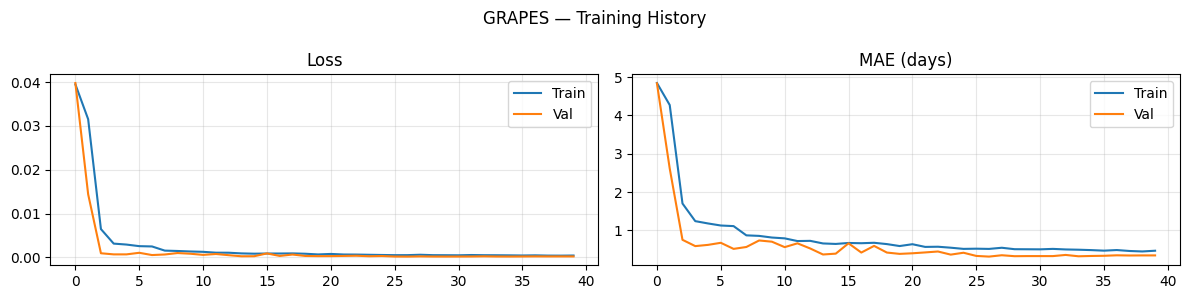


══════════════════════════════════════════════════════════
  ALL TRAINING COMPLETE
══════════════════════════════════════════════════════════
  Fruit                    Val MAE    Test MAE
  ────────────────────────────────────────────
  grapes                    0.31d      0.35d

  Models saved in: /content/fruit_models


In [ ]:
# ════════════════════════════════════════════════
#  CELL 3 — Train ALL fruit models automatically
#  Just press RUN — trains one by one
# ════════════════════════════════════════════════
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import re, warnings
warnings.filterwarnings("ignore")

# ── Config ───────────────────────────────────────
FRUIT_CUTOFF = {
    'grapes' : 20
}

IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 40
LR         = 2e-4
VAL_FRAC   = 0.15
TEST_FRAC  = 0.10
SEED       = 42
DATA_ROOT  = Path("/content/dataset")
SAVE_DIR   = Path("/content/fruit_models")
SAVE_DIR.mkdir(exist_ok=True)
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Fruits : {list(FRUIT_CUTOFF.keys())}\n")

# ── Transforms ───────────────────────────────────
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.3, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1),
                            scale=(0.85, 1.15)),
    transforms.RandomGrayscale(p=0.03),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── Dataset classes ──────────────────────────────
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class FruitDataset(Dataset):
    def __init__(self, samples, cutoff, transform=None):
        self.samples   = samples
        self.cutoff    = cutoff
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, day = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(day / self.cutoff, dtype=torch.float32)

class SplitWrapper(Dataset):
    def __init__(self, subset, cutoff, transform):
        self.subset    = subset
        self.cutoff    = cutoff
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        path, day = self.subset.dataset.samples[self.subset.indices[idx]]
        img    = Image.open(path).convert("RGB")
        target = torch.tensor(day / self.cutoff, dtype=torch.float32)
        return self.transform(img), target

# ── Model ────────────────────────────────────────
def build_model():
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.features[5:].parameters():
        p.requires_grad = True
    in_feat = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feat, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )
    return m.to(DEVICE)

# ── Train / eval ─────────────────────────────────
def mae_days(p, t, cutoff):
    return (torch.abs(p - t) * cutoff).mean().item()

def run_epoch(model, loader, cutoff, optimizer=None, scheduler=None, train=True):
    model.train() if train else model.eval()
    criterion   = nn.SmoothL1Loss()
    total_loss, total_mae, n = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, tgts in loader:
            imgs = imgs.to(DEVICE)
            tgts = tgts.to(DEVICE).unsqueeze(1)
            preds = model(imgs)
            loss  = criterion(preds, tgts)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
            bs          = imgs.size(0)
            total_loss += loss.item() * bs
            total_mae  += mae_days(preds.squeeze(), tgts.squeeze(), cutoff) * bs
            n          += bs
    return total_loss / n, total_mae / n

# ── Main training loop ───────────────────────────
FINAL_RESULTS = {}   # fruit → test_mae

for FRUIT, CUTOFF in FRUIT_CUTOFF.items():

    print(f"\n{'═'*58}")
    print(f"  [{list(FRUIT_CUTOFF.keys()).index(FRUIT)+1}/{len(FRUIT_CUTOFF)}]  "
          f"Training : {FRUIT.upper()}   cutoff=day{CUTOFF}")
    print(f"{'═'*58}")

    DATA_DIR  = DATA_ROOT / FRUIT
    SAVE_PATH = SAVE_DIR  / f"{FRUIT}_model.pt"

    # Check folder exists
    if not DATA_DIR.exists():
        print(f"  ⚠️  Folder not found: {DATA_DIR} — skipping")
        continue

    # Build sample list
    samples = []
    for day_dir in sorted(DATA_DIR.iterdir(),
                          key=lambda p: int(re.search(r'\d+', p.name).group())):
        if not day_dir.is_dir():
            continue
        day_num = int(re.search(r'\d+', day_dir.name).group())
        imgs    = [p for p in day_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
        for p in imgs:
            samples.append((str(p), day_num))

    print(f"  Total samples : {len(samples)}")
    if len(samples) < 10:
        print(f"  ⚠️  Too few samples — skipping")
        continue

    # Split
    n       = len(samples)
    n_val   = max(2, int(n * VAL_FRAC))
    n_test  = max(2, int(n * TEST_FRAC))
    n_train = n - n_val - n_test
    print(f"  Split         : train={n_train}  val={n_val}  test={n_test}")

    full_ds = FruitDataset(samples, CUTOFF, transform=None)
    tr_sub, va_sub, te_sub = random_split(
        full_ds, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(SEED)
    )

    kw = dict(num_workers=2, pin_memory=(DEVICE.type == "cuda"))
    train_loader = DataLoader(SplitWrapper(tr_sub, CUTOFF, train_tfm),
                              batch_size=BATCH_SIZE, shuffle=True,  **kw)
    val_loader   = DataLoader(SplitWrapper(va_sub, CUTOFF, val_tfm),
                              batch_size=BATCH_SIZE, shuffle=False, **kw)
    test_loader  = DataLoader(SplitWrapper(te_sub, CUTOFF, val_tfm),
                              batch_size=BATCH_SIZE, shuffle=False, **kw)

    # Build fresh model for each fruit
    model     = build_model()
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=LR, weight_decay=1e-4)
    scheduler = OneCycleLR(optimizer, max_lr=LR,
                           steps_per_epoch=len(train_loader),
                           epochs=EPOCHS, pct_start=0.15)

    history  = {"tr_loss":[], "vl_loss":[], "tr_mae":[], "vl_mae":[]}
    best_mae = float("inf")

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_mae = run_epoch(model, train_loader, CUTOFF,
                                    optimizer, scheduler, train=True)
        vl_loss, vl_mae = run_epoch(model, val_loader,   CUTOFF,
                                    train=False)

        history["tr_loss"].append(tr_loss)
        history["vl_loss"].append(vl_loss)
        history["tr_mae"].append(tr_mae)
        history["vl_mae"].append(vl_mae)

        if vl_mae < best_mae:
            best_mae = vl_mae
            torch.save({
                "state_dict": model.state_dict(),
                "fruit":      FRUIT,
                "cutoff":     CUTOFF,
                "val_mae":    vl_mae,
                "epoch":      epoch,
            }, SAVE_PATH)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  ep {epoch:3d}/{EPOCHS} | "
                  f"loss {tr_loss:.4f}/{vl_loss:.4f} | "
                  f"MAE {tr_mae:.2f}/{vl_mae:.2f} days | "
                  f"best {best_mae:.2f}d")

    # Test
    ckpt = torch.load(SAVE_PATH)
    model.load_state_dict(ckpt["state_dict"])
    _, test_mae = run_epoch(model, test_loader, CUTOFF, train=False)
    FINAL_RESULTS[FRUIT] = {"test_mae": test_mae, "val_mae": best_mae}
    print(f"  ✅ Saved → {SAVE_PATH}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
    fig.suptitle(f"{FRUIT.upper()} — Training History", fontsize=12)
    ax1.plot(history["tr_loss"], label="Train")
    ax1.plot(history["vl_loss"], label="Val")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(history["tr_mae"], label="Train")
    ax2.plot(history["vl_mae"], label="Val")
    ax2.set_title("MAE (days)"); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/content/{FRUIT}_training.png", dpi=90)
    plt.show()

    # Free GPU memory before next fruit
    del model, optimizer, scheduler
    torch.cuda.empty_cache()

# ── Final Summary ────────────────────────────────
print(f"\n{'═'*58}")
print(f"  ALL TRAINING COMPLETE")
print(f"{'═'*58}")
print(f"  {'Fruit':20s}  {'Val MAE':>10}  {'Test MAE':>10}")
print(f"  {'─'*44}")
for fruit, res in FINAL_RESULTS.items():
    print(f"  {fruit:20s}  {res['val_mae']:>8.2f}d  {res['test_mae']:>8.2f}d")
print(f"\n  Models saved in: {SAVE_DIR}")